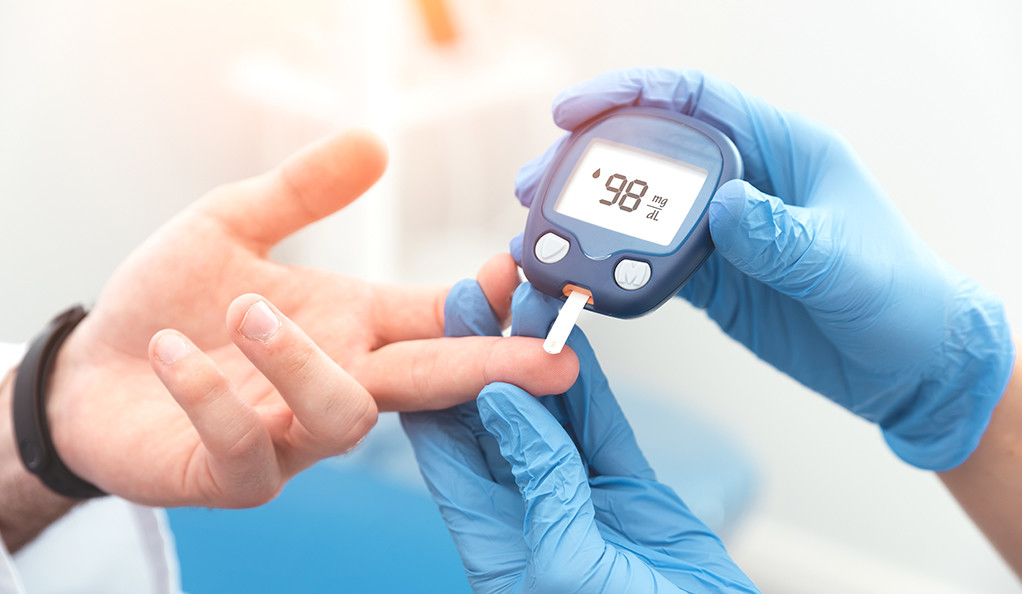

In [1]:
import pandas as pd
import numpy as np

def generate_diabetes_dataset(n=500, noise_ratio=0.1, seed=42):
    np.random.seed(seed)

    half = n // 2
    noise_n = int(n * noise_ratio / 2)

    # ======================
    # Healthy (0)
    # ======================
    healthy = pd.DataFrame({
        "blood_sugar": np.random.randint(70, 125, half),
        "blood_pressure": np.random.randint(65, 90, half),
        "diabetes": 0
    })

    # ======================
    # Diabetic (1)
    # ======================
    diabetic = pd.DataFrame({
        "blood_sugar": np.random.randint(130, 220, half),
        "blood_pressure": np.random.randint(80, 125, half),
        "diabetes": 1
    })

    # ======================
    # Noise (mixing the classes)
    # ======================
    healthy_noise = pd.DataFrame({
        "blood_sugar": np.random.randint(120, 145, noise_n),
        "blood_pressure": np.random.randint(80, 100, noise_n),
        "diabetes": 0
    })

    diabetic_noise = pd.DataFrame({
        "blood_sugar": np.random.randint(105, 135, noise_n),
        "blood_pressure": np.random.randint(70, 95, noise_n),
        "diabetes": 1
    })

    # ======================
    # Combine
    # ======================
    df = pd.concat(
        [healthy, diabetic, healthy_noise, diabetic_noise],
        ignore_index=True
    )

    # Shuffle
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df

df = generate_diabetes_dataset()

In [2]:
df

,blood_sugar,blood_pressure,diabetes
0,113,66,0
1,98,72,0
2,205,116,1
3,94,76,0
4,125,93,0
...,...,...,...
545,109,65,0
546,84,81,0
547,205,104,1
548,201,101,1


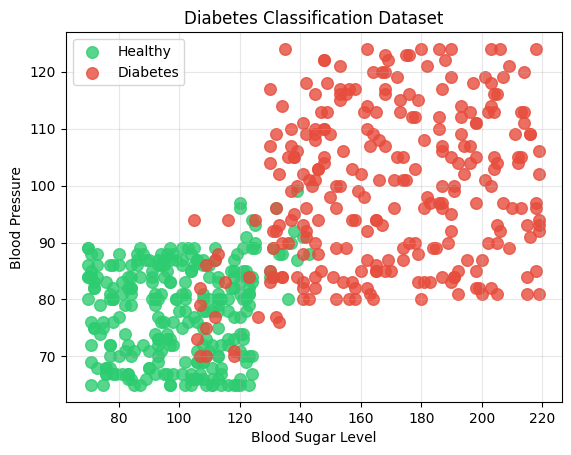

In [3]:
import matplotlib.pyplot as plt

labels = {
    0: "Healthy",
    1: "Diabetes"
}

colors = {
    0: "#2ECC71",   # green
    1: "#E74C3C"    # red
}

for label in [0, 1]:
    subset = df[df["diabetes"] == label]

    plt.scatter(
        subset["blood_sugar"],
        subset["blood_pressure"],
        label=labels[label],
        color=colors[label],
        s=70,          # גודל נקודות
        alpha=0.8      # שקיפות קלה
    )

plt.xlabel("Blood Sugar Level")
plt.ylabel("Blood Pressure")
plt.title("Diabetes Classification Dataset")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X = df[["blood_sugar", "blood_pressure"]]
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
import numpy as np

class RandomClassifier:
    def fit(self, X, y):
        # לא צריך ללמוד כלום
        pass

    def predict(self, X):
        return np.random.randint(0, 2, size=len(X))

In [6]:
model = RandomClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Accuracy: 0.52


In [8]:
from sklearn.model_selection import train_test_split

X = df[["blood_sugar", "blood_pressure"]]
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [10]:
y_pred = knn.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")



Accuracy: 0.94


In [12]:
for k in [1, 3, 5, 7, 11,30,100]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    print(f"k={k} -> Accuracy: {accuracy_score(y_test, y_pred):.2f}")

k=1 -> Accuracy: 0.94
k=3 -> Accuracy: 0.94
k=5 -> Accuracy: 0.94
k=7 -> Accuracy: 0.95
k=11 -> Accuracy: 0.95
k=30 -> Accuracy: 0.94
k=100 -> Accuracy: 0.95


# Streamlit Code:
import streamlit as st
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ======================
# Dataset
# ======================
def generate_diabetes_dataset(n=500, noise_ratio=0.1, seed=42):
    np.random.seed(seed)

    half = n // 2
    noise_n = int(n * noise_ratio / 2)

    # ======================
    # Healthy (0)
    # ======================
    healthy = pd.DataFrame({
        "blood_sugar": np.random.randint(70, 125, half),
        "blood_pressure": np.random.randint(65, 90, half),
        "diabetes": 0
    })

    # ======================
    # Diabetic (1)
    # ======================
    diabetic = pd.DataFrame({
        "blood_sugar": np.random.randint(130, 220, half),
        "blood_pressure": np.random.randint(80, 125, half),
        "diabetes": 1
    })

    # ======================
    # Noise (mixing the classes)
    # ======================
    healthy_noise = pd.DataFrame({
        "blood_sugar": np.random.randint(120, 145, noise_n),
        "blood_pressure": np.random.randint(80, 100, noise_n),
        "diabetes": 0
    })

    diabetic_noise = pd.DataFrame({
        "blood_sugar": np.random.randint(105, 135, noise_n),
        "blood_pressure": np.random.randint(70, 95, noise_n),
        "diabetes": 1
    })

    # ======================
    # Combine
    # ======================
    df = pd.concat(
        [healthy, diabetic, healthy_noise, diabetic_noise],
        ignore_index=True
    )

    # Shuffle
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df

df = generate_diabetes_dataset()
# ==============================================================================================


# ======================
# Model
# ======================
X = df[["blood_sugar", "blood_pressure"]]
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
# ==============================================================================================

# ======================
# Sidebar
# ======================
st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Choose a section",
    ["Dataset", "Model Performance", "Make Prediction"]
)

# ======================
# Page 1: Dataset
# ======================
if page == "Dataset":
    st.title("Dataset")

    st.subheader("Data")
    st.dataframe(df)

    st.subheader("Scatter Plot")

    st.scatter_chart(
        df,
        x="blood_sugar",
        y="blood_pressure",
        color="diabetes"
    )

# ======================
# Page 2: Performance
# ======================
elif page == "Model Performance":
    st.title("Model Performance")

    st.metric("Accuracy", f"{accuracy:.2f}")

# ======================
# Page 3: Prediction
# ======================
elif page == "Make Prediction":
    st.title("Predict Diabetes")

    blood_sugar = st.slider("Blood Sugar", 70, 220, 120)
    blood_pressure = st.slider("Blood Pressure", 60, 130, 80)

    if st.button("Predict"):
        input_data = np.array([[blood_sugar, blood_pressure]])
        prediction = knn.predict(input_data)[0]

        if prediction == 0:
            label = "Healthy"
        else:
            label = "Diabetes"

        st.subheader(f"Prediction: {label}")

        # ======================
        # Add point to plot
        # ======================
        new_point = pd.DataFrame({
            "blood_sugar": [blood_sugar],
            "blood_pressure": [blood_pressure],
            "diabetes": [2]  # new category
        })

        plot_df = pd.concat([df, new_point], ignore_index=True)

        st.subheader("Visualization")

        st.scatter_chart(
            plot_df,
            x="blood_sugar",
            y="blood_pressure",
            color="diabetes"
        )

# Real Datasets:

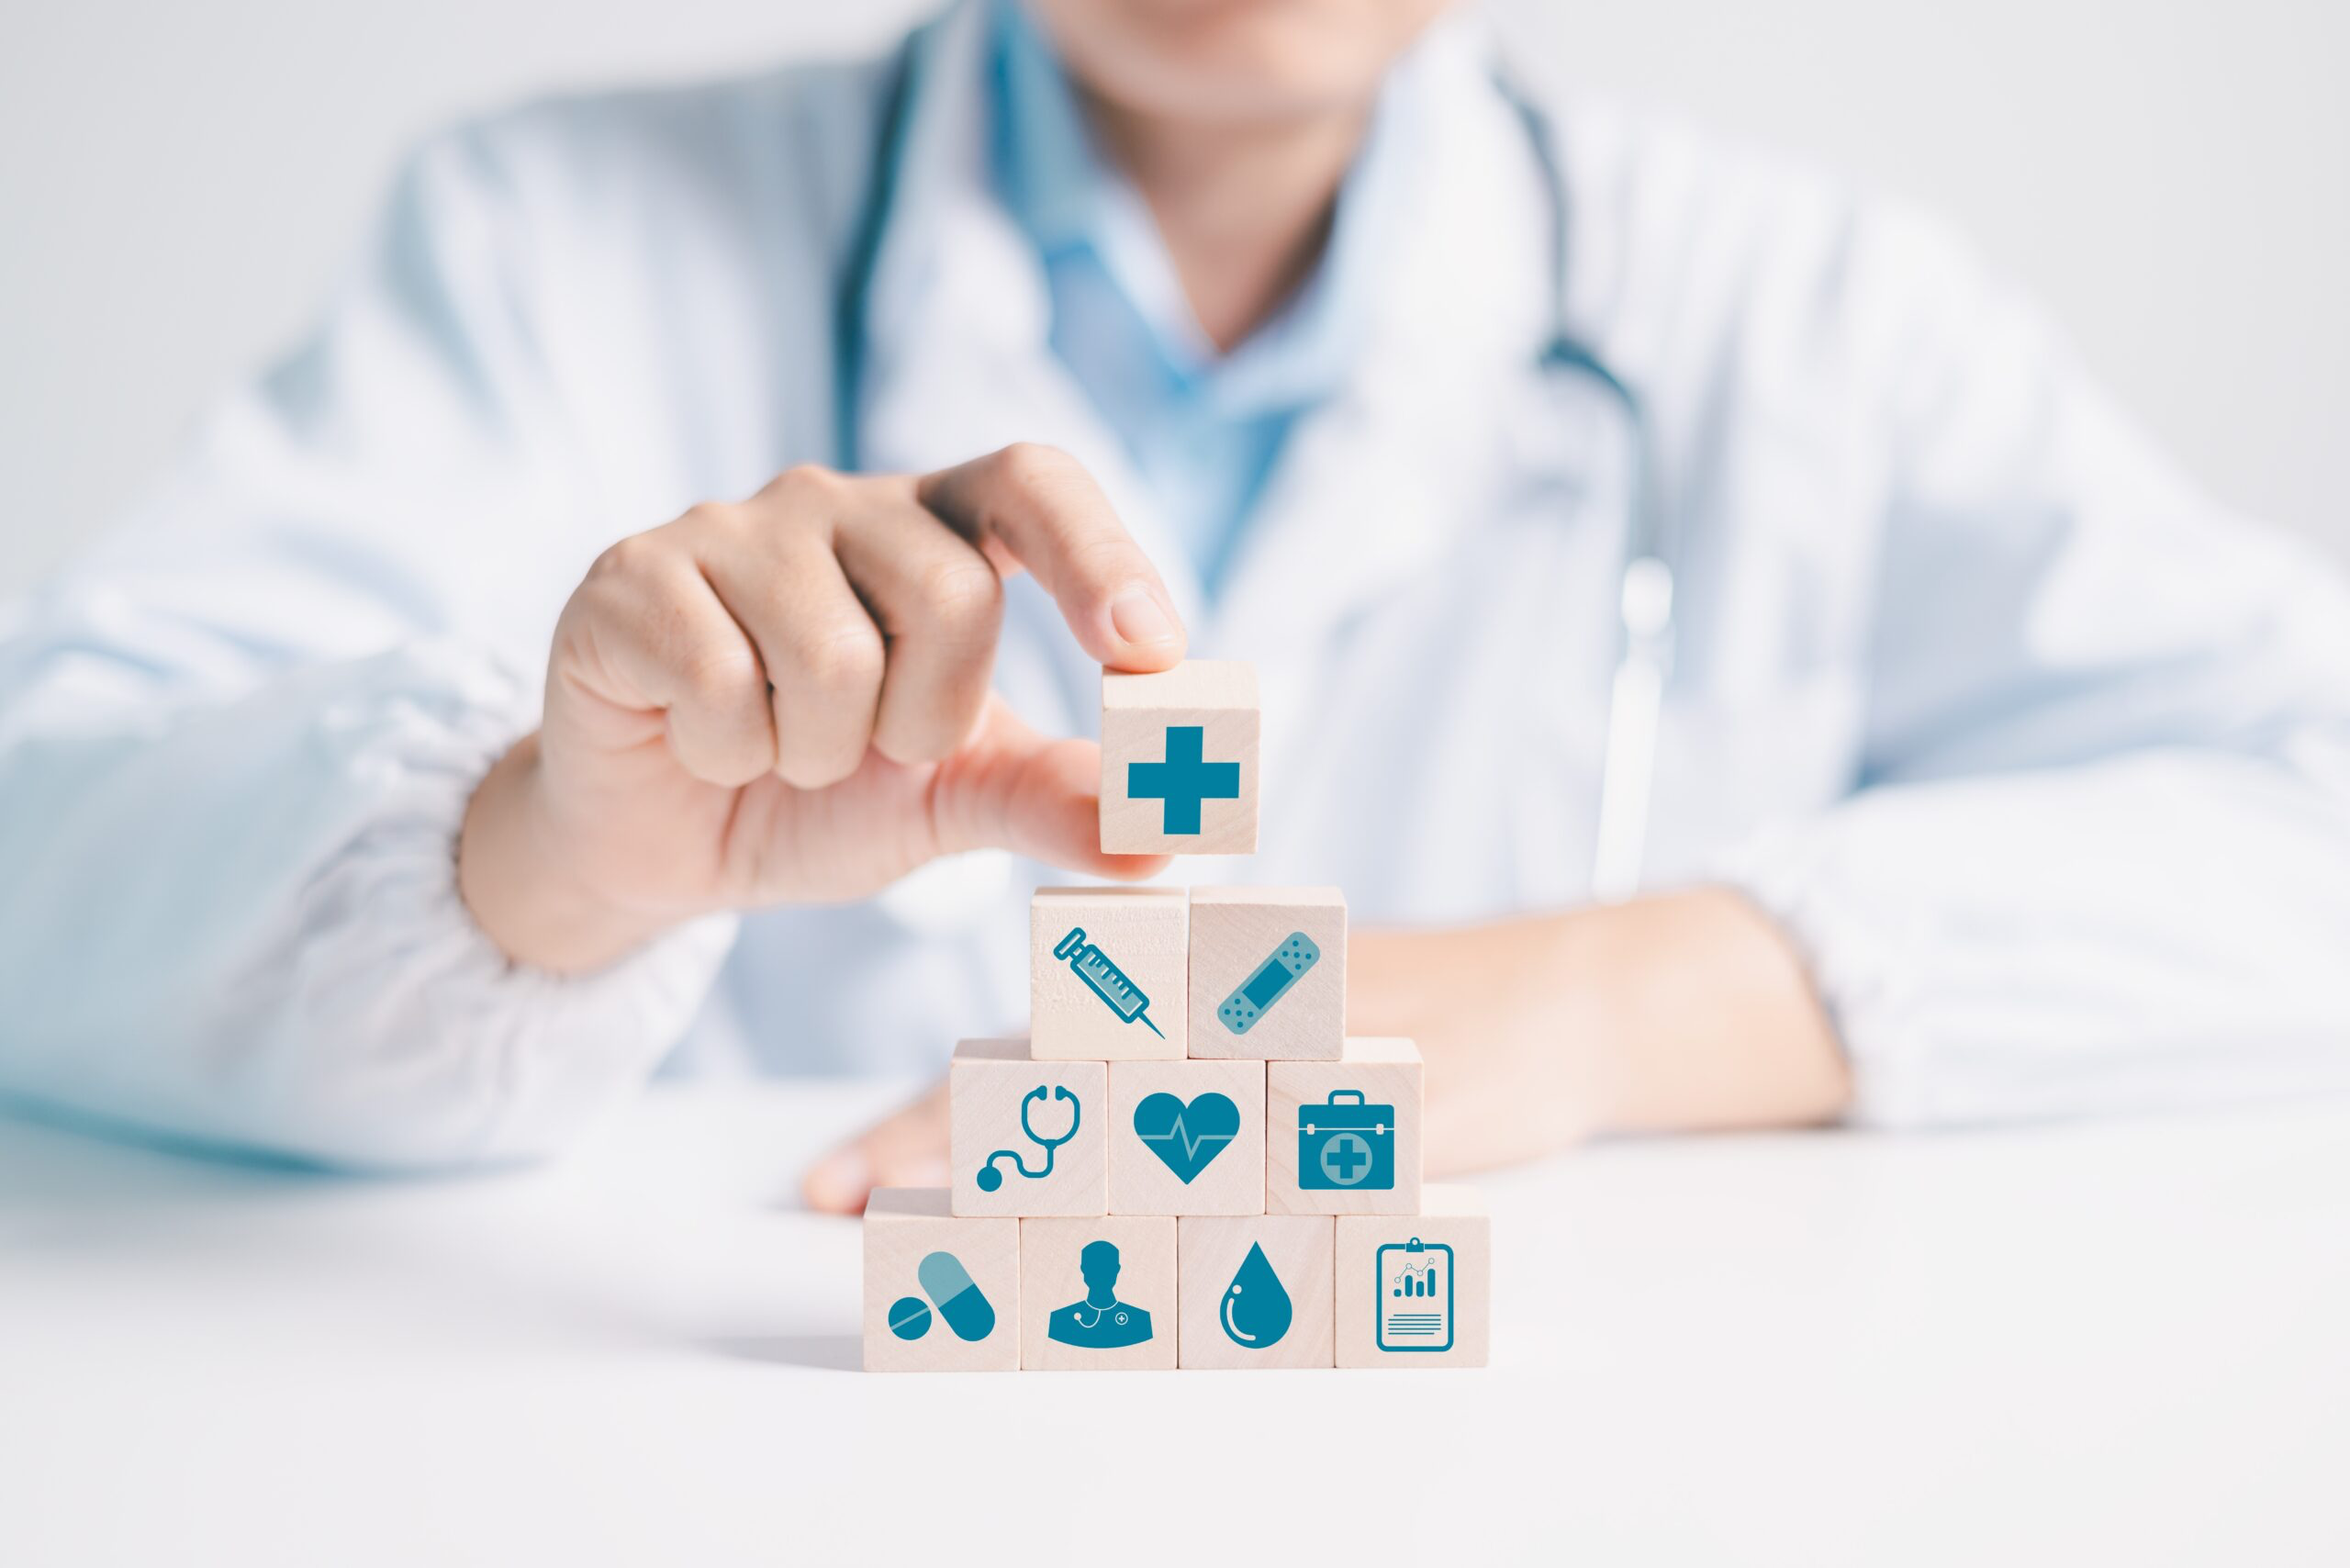

In [13]:
import kagglehub
import pandas as pd
import os


def load_stroke_data():
    # הורדה
    path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

    print("Path to dataset files:", path)

    # קבצים בתיקייה
    files = os.listdir(path)
    print("Files:", files)

    # נתיב לקובץ CSV
    csv_path = os.path.join(path, files[0])

    # קריאה לדאטה
    df = pd.read_csv(csv_path)

    # בחירת עמודות
    df = df[["stroke", "bmi", "avg_glucose_level", "age"]]

    # מילוי ערכים חסרים עם ממוצע
    df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
    df["avg_glucose_level"] = df["avg_glucose_level"].fillna(df["avg_glucose_level"].mean())
    df["age"] = df["age"].fillna(df["age"].mean())

    return df


# זימון הפונקציה
df = load_stroke_data()

df

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/stroke-prediction-dataset
Files: ['healthcare-dataset-stroke-data.csv']


,stroke,bmi,avg_glucose_level,age
0,1,36.600000,228.69,67.0
1,1,28.893237,202.21,61.0
2,1,32.500000,105.92,80.0
3,1,34.400000,171.23,49.0
4,1,24.000000,174.12,79.0
...,...,...,...,...
5105,0,28.893237,83.75,80.0
5106,0,40.000000,125.20,81.0
5107,0,30.600000,82.99,35.0
5108,0,25.600000,166.29,51.0


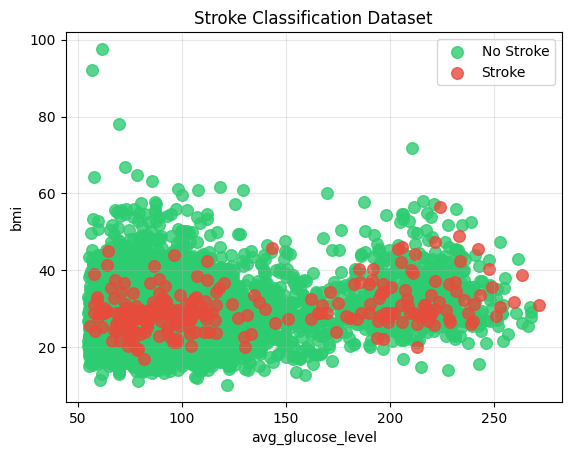

In [14]:
import matplotlib.pyplot as plt

labels = {
    0: "No Stroke",
    1: "Stroke"
}

colors = {
    0: "#2ECC71",   # green
    1: "#E74C3C"    # red
}

for label in [0, 1]:
    subset = df[df["stroke"] == label]

    plt.scatter(
        subset["avg_glucose_level"],
        subset["bmi"],
        label=labels[label],
        color=colors[label],
        s=70,          # גודל נקודות
        alpha=0.8      # שקיפות קלה
    )

plt.xlabel("avg_glucose_level")
plt.ylabel("bmi")
plt.title("Stroke Classification Dataset")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

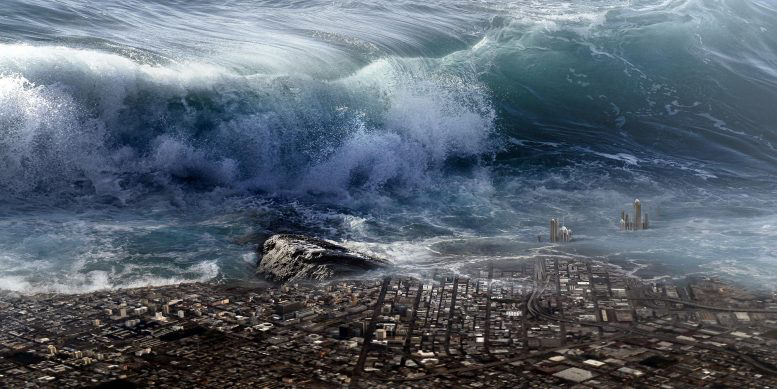

In [15]:
import kagglehub
import pandas as pd
import os


def load_earthquake_data():
    # הורדה
    path = kagglehub.dataset_download(
        "ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset"
    )

    print("Path to dataset files:", path)

    # קבצים
    files = os.listdir(path)
    print("Files:", files)

    # קריאה
    csv_path = os.path.join(path, files[0])
    df = pd.read_csv(csv_path)

    # ננרמל שמות עמודות לאותיות קטנות (עוזר מאוד)
    df.columns = df.columns.str.lower()

    # הפיצ'רים שביקשת
    selected_cols = ["tsunami", "longitude", "latitude", "depth", "magnitude"]

    # נשמור רק עמודות שקיימות
    selected_cols = [col for col in selected_cols if col in df.columns]

    df = df[selected_cols]

    # ===== ניקוי =====
    # מילוי ערכים חסרים בעמודות מספריות
    df.fillna(df.mean(numeric_only=True), inplace=True)

    return df


# זימון
df = load_earthquake_data()

df

100%|██████████| 15.8k/15.8k [00:00<00:00, 14.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset/versions/1
Files: ['earthquake_data_tsunami.csv']


,tsunami,longitude,latitude,depth,magnitude
0,1,159.596,-9.7963,14.000,7.0
1,0,100.738,-4.9559,25.000,6.9
2,1,-178.346,-20.0508,579.000,7.0
3,1,-172.129,-19.2918,37.000,7.3
4,1,178.278,-25.5948,624.464,6.6
...,...,...,...,...,...
777,0,-88.660,13.0490,60.000,7.7
778,0,-153.281,56.7744,36.400,6.9
779,0,167.170,-14.9280,103.000,7.1
780,0,126.899,6.6310,33.000,6.8


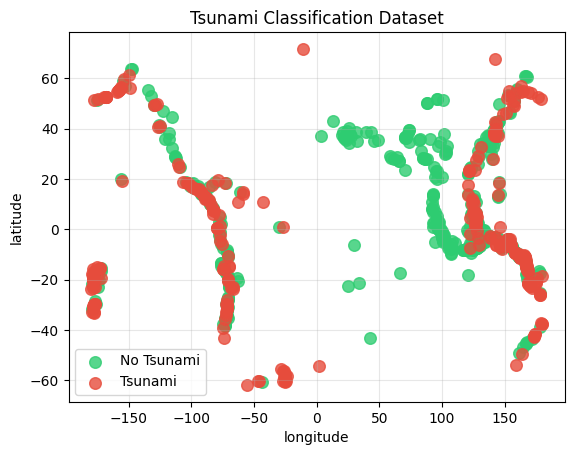

In [16]:
import matplotlib.pyplot as plt

labels = {
    0: "No Tsunami",
    1: "Tsunami"
}

colors = {
    0: "#2ECC71",   # green
    1: "#E74C3C"    # red
}

for label in [0, 1]:
    subset = df[df["tsunami"] == label]

    plt.scatter(
        subset["longitude"],
        subset["latitude"],
        label=labels[label],
        color=colors[label],
        s=70,          # גודל נקודות
        alpha=0.8      # שקיפות קלה
    )

plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("Tsunami Classification Dataset")

plt.legend()
plt.grid(alpha=0.3)

plt.show()